In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import pickle
from scipy.spatial import cKDTree

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import smooth_esp_params_depth, composite_eddy_velocity


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


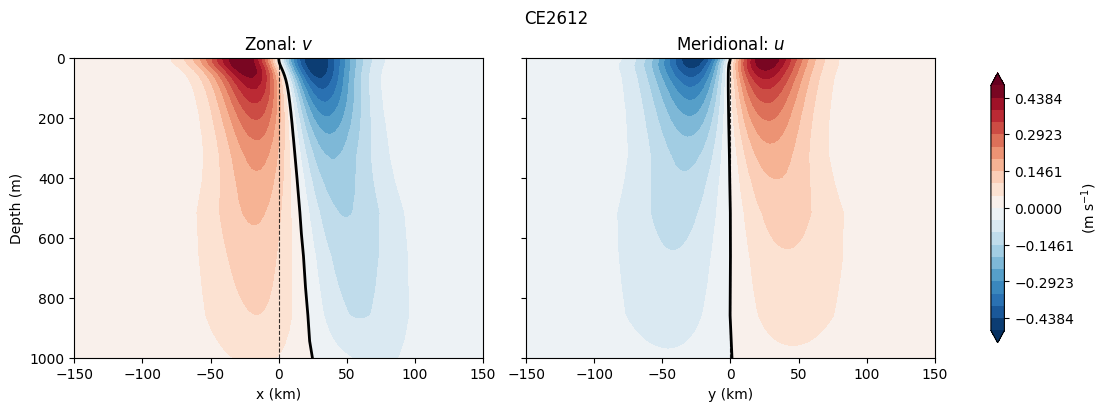

In [4]:
_ = composite_eddy_velocity(
    eddy=2612,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True
)


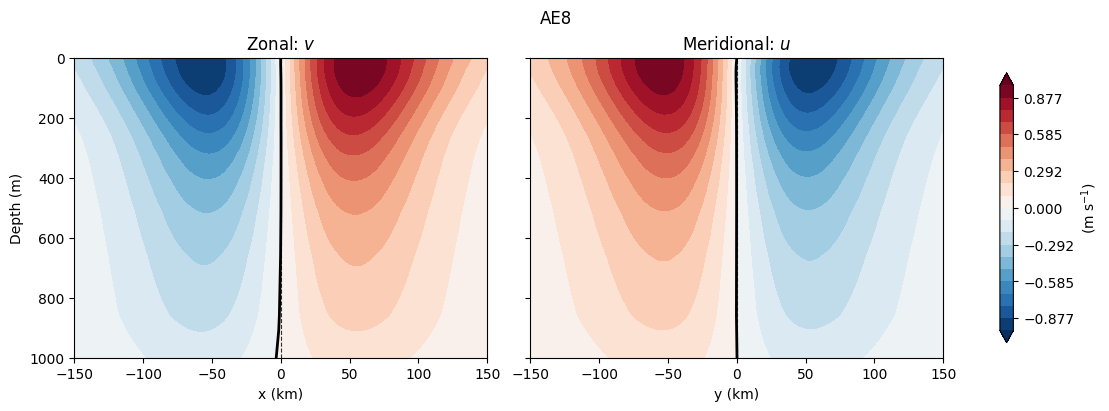

In [5]:
_ = composite_eddy_velocity(
    eddy=8,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    smooth_params=True
)


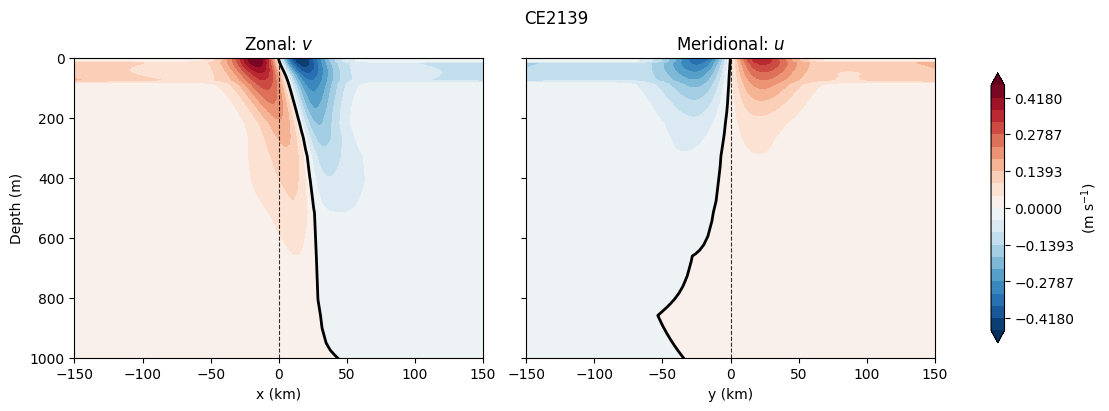

In [6]:
_ = composite_eddy_velocity(
    eddy=2139,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    smooth_params=True
)


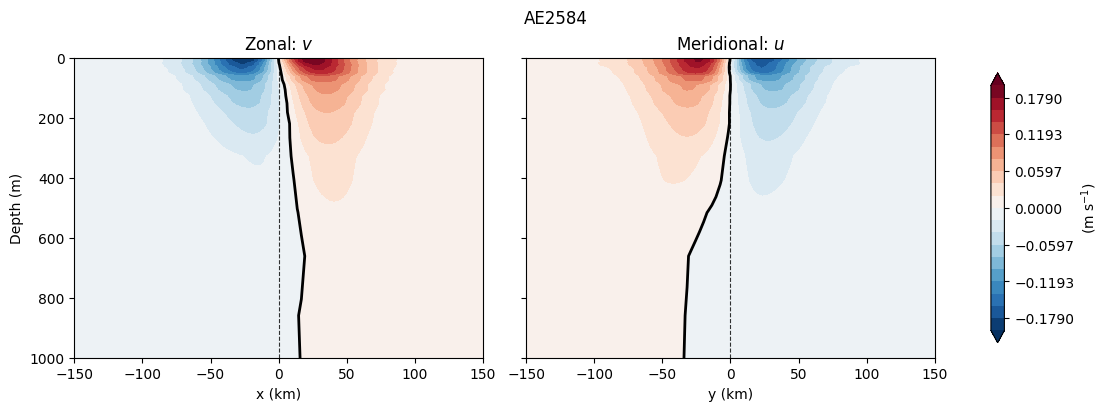

In [7]:
_ = composite_eddy_velocity(
    eddy=2584,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    smooth_params=True
)


In [8]:
# ---------------- six-bin region grid ----------------
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6

tree = cKDTree(
    np.column_stack([X_grid.ravel(), Y_grid.ravel()])
)

_, idx = tree.query(
    np.column_stack([df_eddies.xc, df_eddies.yc])
)

region_map = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

df_eddies['Region'] = (
    pd.Series(bin_grid.ravel()[idx])
      .map(region_map)
)


In [9]:
def regional_composite_eddy_velocity(
    df_region,
    dic_vert,
    z_r,
    xlim_km=150,
    nx=100,
    ny=100,
    zmax=1.2e3,
    smooth_params=True,
    smooth_window=5,
    remove_outliers=True,
    ensemble=False,
    ensemble_frac=0.9,
    n_ensemble=11,
    random_state=0,
    plot=True,
    zlim=1000,
    levels=20,
    cmap='RdBu_r',
    title='Regional composite',
    vcmax=.5
):
    """
    Regional AE/CE composite.

    If ensemble=False:
        Uses all eddy-days in df_region.

    If ensemble=True:
        Repeats composite construction n_ensemble times, each using a random
        fraction of eddies. Returns ensemble mean and std.
    """

    rng = np.random.default_rng(random_state)

    x = np.linspace(-xlim_km, xlim_km, nx) * 1e3
    y = np.linspace(-xlim_km, xlim_km, ny) * 1e3

    z_grid = np.insert(np.abs(z_r[150, 150, 1:]), 0, 0)
    z_grid = z_grid[z_grid < zmax]

    X, Y = np.meshgrid(x, y, indexing='ij')
    nz = len(z_grid)

    def _make_composite(df_sub):

        U_sum = np.zeros((nx, ny, nz))
        V_sum = np.zeros((nx, ny, nz))
        n_profiles = 0

        eddies = df_sub.Eddy.dropna().unique()

        for eddy in eddies:

            key = f'Eddy{int(eddy)}'

            if key not in dic_vert:
                continue

            valid_days = set(
                df_sub.loc[df_sub.Eddy == eddy, 'Day'].astype(int)
            )

            for day, df in dic_vert[key].items():

                if isinstance(day, str):
                    day_num = int(day.replace('Day', ''))
                else:
                    day_num = int(day)

                if day_num not in valid_days:
                    continue

                df = df.copy().sort_values('Depth')

                if len(df) == 0:
                    continue

                if smooth_params:
                    df = smooth_esp_params_depth(
                        df,
                        window=smooth_window,
                        remove_outliers=remove_outliers,
                        z_col='Depth'
                    )
                else:
                    df['q11'] = df['Q'].apply(lambda Q: Q[0, 0] if Q is not None else np.nan)
                    df['q12'] = df['Q'].apply(lambda Q: Q[0, 1] if Q is not None else np.nan)
                    df['q22'] = df['Q'].apply(lambda Q: Q[1, 1] if Q is not None else np.nan)

                df['xc'] -= df['xc'].iloc[0]
                df['yc'] -= df['yc'].iloc[0]

                U = np.zeros((nx, ny, nz))
                V = np.zeros((nx, ny, nz))

                for _, data in df.iterrows():

                    vals = [
                        data.xc, data.yc,
                        data.q11, data.q12, data.q22,
                        data.Omega, data.Rc
                    ]

                    if not np.all(np.isfinite(vals)):
                        continue

                    if data.Rc <= 0:
                        continue

                    k = np.argmin(np.abs(z_grid - abs(data.Depth)))

                    dx = X - data.xc * 1e3
                    dy = Y - data.yc * 1e3

                    rho2 = (
                        data.q11 * dx**2
                        + 2 * data.q12 * dx * dy
                        + data.q22 * dy**2
                    )

                    fac = data.Omega * np.exp(-rho2 / (data.Rc * 1e3)**2)

                    U[:, :, k] = -fac * (data.q12*dx + data.q22*dy)
                    V[:, :, k] =  fac * (data.q11*dx + data.q12*dy)

                U = np.nan_to_num(U, nan=0.0, posinf=0.0, neginf=0.0)
                V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)

                U_sum += U
                V_sum += V
                n_profiles += 1

        if n_profiles == 0:
            return (
                np.full((nx, ny, nz), np.nan),
                np.full((nx, ny, nz), np.nan),
                0
            )

        return U_sum / n_profiles, V_sum / n_profiles, n_profiles

    def _single_or_ensemble(df_sub):

        if not ensemble:
            U, V, n = _make_composite(df_sub)
            return U, V, None, None, n

        eddies = np.sort(df_sub.Eddy.dropna().unique())

        if len(eddies) == 0:
            nan_field = np.full((nx, ny, nz), np.nan)
            return nan_field, nan_field, nan_field, nan_field, 0

        n_sample = max(1, int(np.ceil(ensemble_frac * len(eddies))))

        U_list = []
        V_list = []
        n_profiles_list = []

        for _ in range(n_ensemble):

            sample_eddies = rng.choice(
                eddies,
                size=n_sample,
                replace=False
            )

            df_sample = df_sub[df_sub.Eddy.isin(sample_eddies)]

            U, V, n = _make_composite(df_sample)

            U_list.append(U)
            V_list.append(V)
            n_profiles_list.append(n)

        U_mean = np.nanmean(U_list, axis=0)
        V_mean = np.nanmean(V_list, axis=0)

        U_std = np.nanstd(U_list, axis=0)
        V_std = np.nanstd(V_list, axis=0)

        n_mean = int(np.nanmean(n_profiles_list))

        return U_mean, V_mean, U_std, V_std, n_mean

    U_AE, V_AE, U_AE_std, V_AE_std, n_AE = _single_or_ensemble(
        df_region[df_region.Cyc == 'AE']
    )

    U_CE, V_CE, U_CE_std, V_CE_std, n_CE = _single_or_ensemble(
        df_region[df_region.Cyc == 'CE']
    )

    if not plot:
        if ensemble:
            return {
                'X': X,
                'Y': Y,
                'z_grid': z_grid,
                'U_AE': U_AE,
                'V_AE': V_AE,
                'U_CE': U_CE,
                'V_CE': V_CE,
                'U_AE_std': U_AE_std,
                'V_AE_std': V_AE_std,
                'U_CE_std': U_CE_std,
                'V_CE_std': V_CE_std,
                'n_AE': n_AE,
                'n_CE': n_CE,
            }

        return X, Y, z_grid, U_AE, V_AE, U_CE, V_CE

    ix0 = np.argmin(np.abs(x))
    iy0 = np.argmin(np.abs(y))

    vmax = min(np.nanmax(np.abs([U_AE, V_AE, U_CE, V_CE])), vcmax)
    clevels = np.linspace(-vmax, vmax, levels + 1)

    fig, axs = plt.subplots(
        2, 2,
        figsize=(11, 8),
        sharex='col',
        sharey=True,
        constrained_layout=True
    )

    ens_label = ' ensemble mean' if ensemble else ''

    plot_data = [
        (axs[0, 0], x / 1e3, V_AE[:, iy0, :].T, f'AE zonal: $v${ens_label}  n={n_AE}', 'x (km)'),
        (axs[0, 1], y / 1e3, U_AE[ix0, :, :].T, f'AE meridional: $u${ens_label}  n={n_AE}', 'y (km)'),
        (axs[1, 0], x / 1e3, V_CE[:, iy0, :].T, f'CE zonal: $v${ens_label}  n={n_CE}', 'x (km)'),
        (axs[1, 1], y / 1e3, U_CE[ix0, :, :].T, f'CE meridional: $u${ens_label}  n={n_CE}', 'y (km)'),
    ]

    m = None

    for ax, coord, field, ax_title, xlabel in plot_data:

        m = ax.contourf(
            coord,
            z_grid,
            field,
            levels=clevels,
            cmap=cmap,
            extend='both'
        )

        ax.contour(
            coord,
            z_grid,
            field,
            levels=[0],
            colors='k',
            linewidths=2
        )

        ax.axvline(0, color='k', lw=0.8)
        ax.set_title(ax_title)
        ax.set_xlabel(xlabel)
        ax.set_ylim(zlim, 0)

    axs[0, 0].set_ylabel('Depth (m)')
    axs[1, 0].set_ylabel('Depth (m)')

    cbar = fig.colorbar(m, ax=axs, location='right', shrink=0.9)
    cbar.set_label('Velocity (m s$^{-1}$)')

    fig.suptitle(title)

    if ensemble:
        return {
            'X': X,
            'Y': Y,
            'z_grid': z_grid,
            'U_AE': U_AE,
            'V_AE': V_AE,
            'U_CE': U_CE,
            'V_CE': V_CE,
            'U_AE_std': U_AE_std,
            'V_AE_std': V_AE_std,
            'U_CE_std': U_CE_std,
            'V_CE_std': V_CE_std,
            'n_AE': n_AE,
            'n_CE': n_CE,
            'fig': fig,
            'axs': axs,
        }

    return X, Y, z_grid, U_AE, V_AE, U_CE, V_CE, fig, axs



In [10]:
dic_regions = {}

region_groups = {
    'S':  ['S1', 'S2'],
    'S1': ['S1'],
    'S2': ['S2'],
    'U':  ['U1', 'U2'],
    'U1': ['U1'],
    'U2': ['U2'],
    'D':  ['D1', 'D2'],
    'D1': ['D1'],
    'D2': ['D2'],
}

for region, allowed_regions in region_groups.items():

    eddies = (
        df_eddies
        .groupby('Eddy')['Region']
        .filter(lambda x: x.isin(allowed_regions).all())
        .index
    )

    dic_regions[region] = df_eddies.loc[eddies].copy()
    

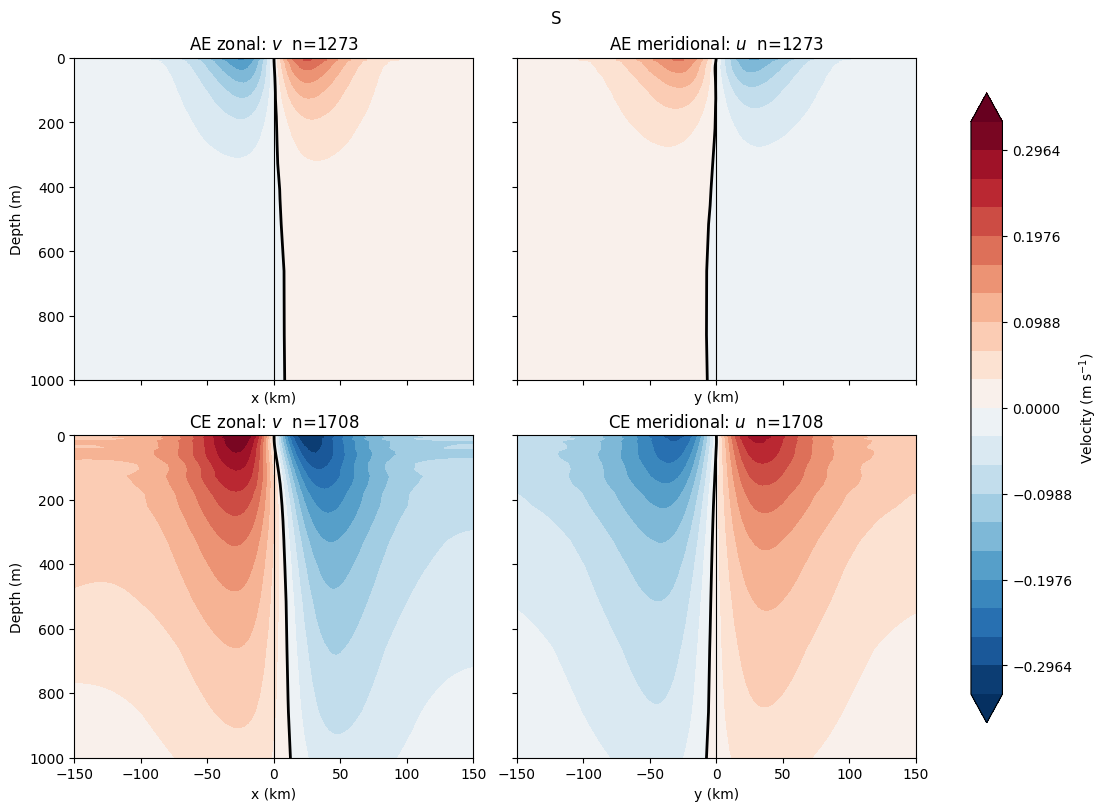

In [11]:
region = 'S'
_ = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region,
    ensemble=False
)


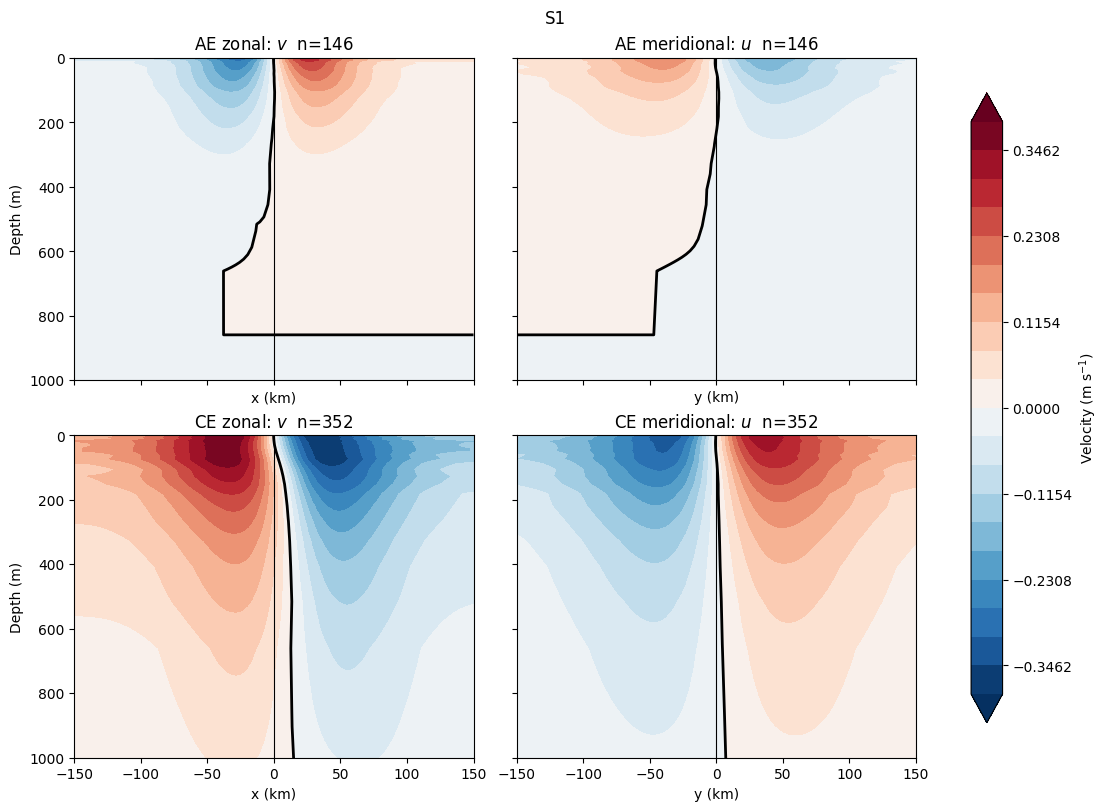

In [12]:
region = 'S1'
_ = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


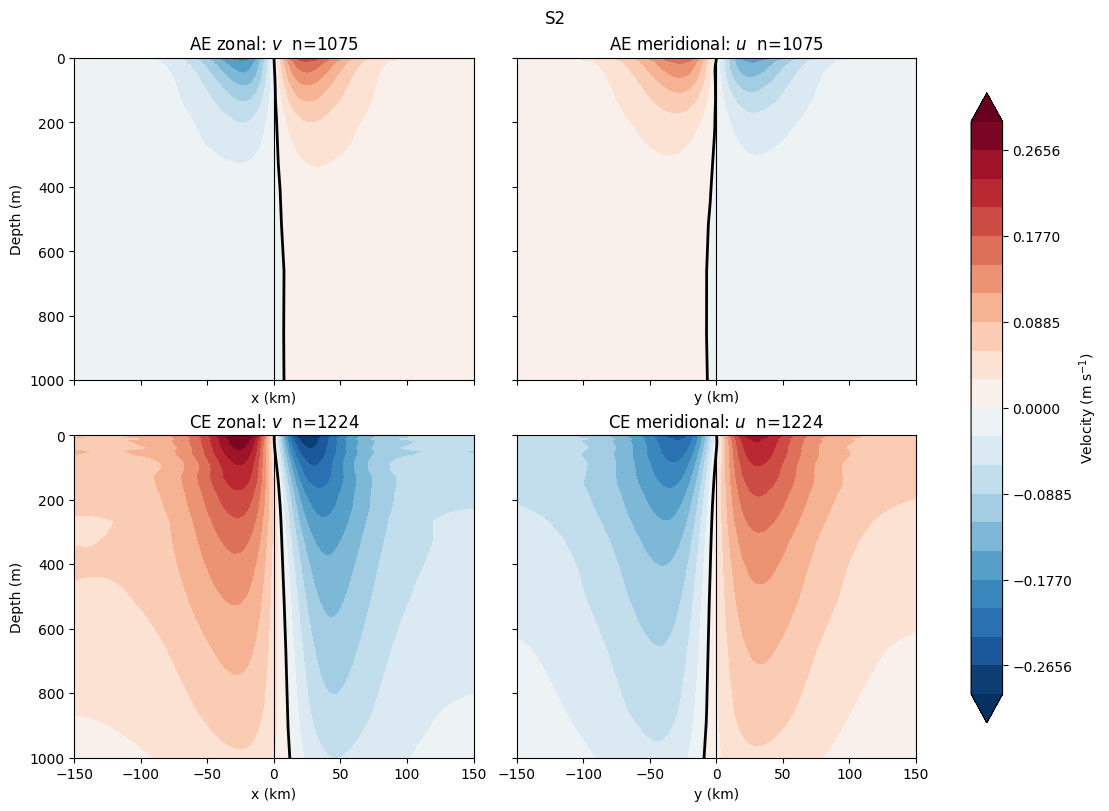

In [13]:
region = 'S2'
_ = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


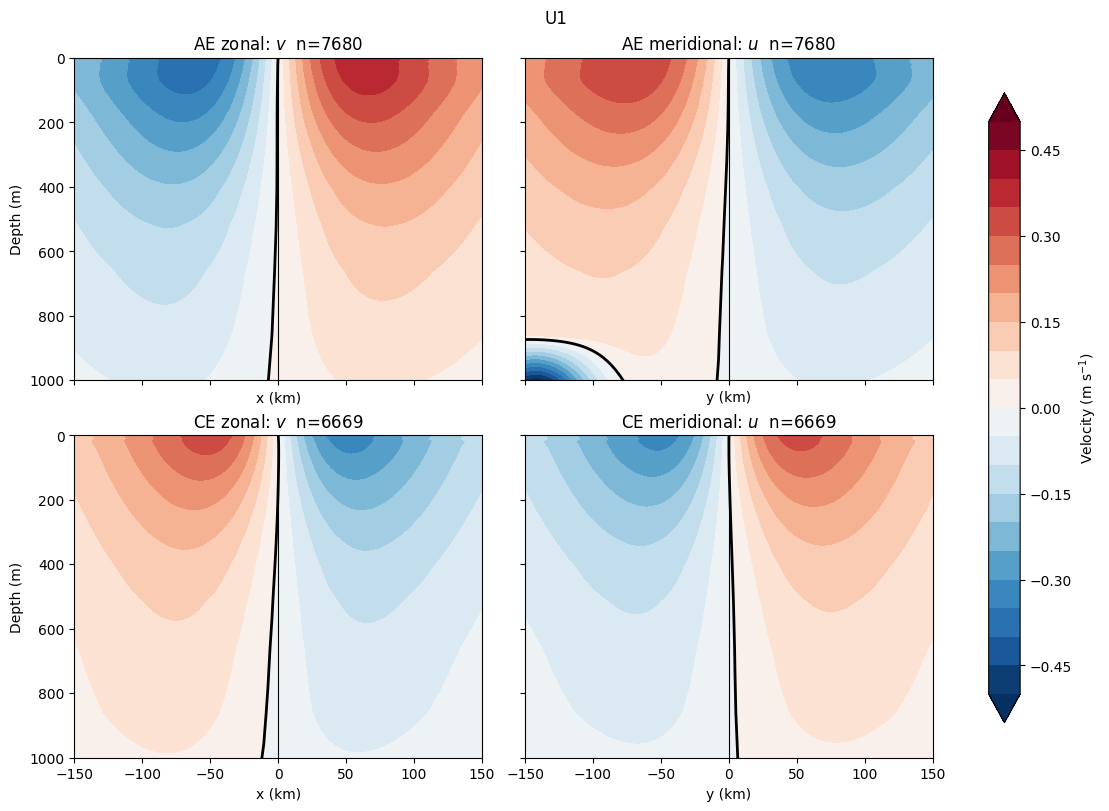

In [14]:
region = 'U1'
X, Y, z_grid, U_AE, V_AE, U_CE, V_CE, fig, axs = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


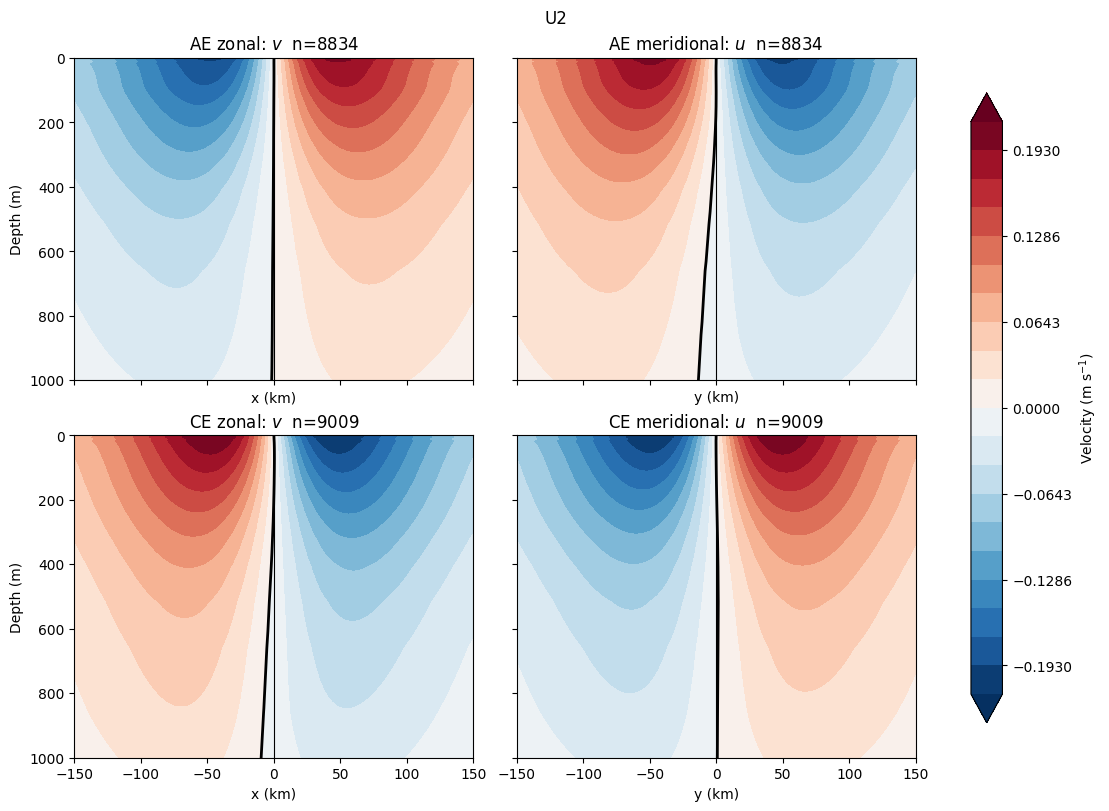

In [15]:
region = 'U2'
_ = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


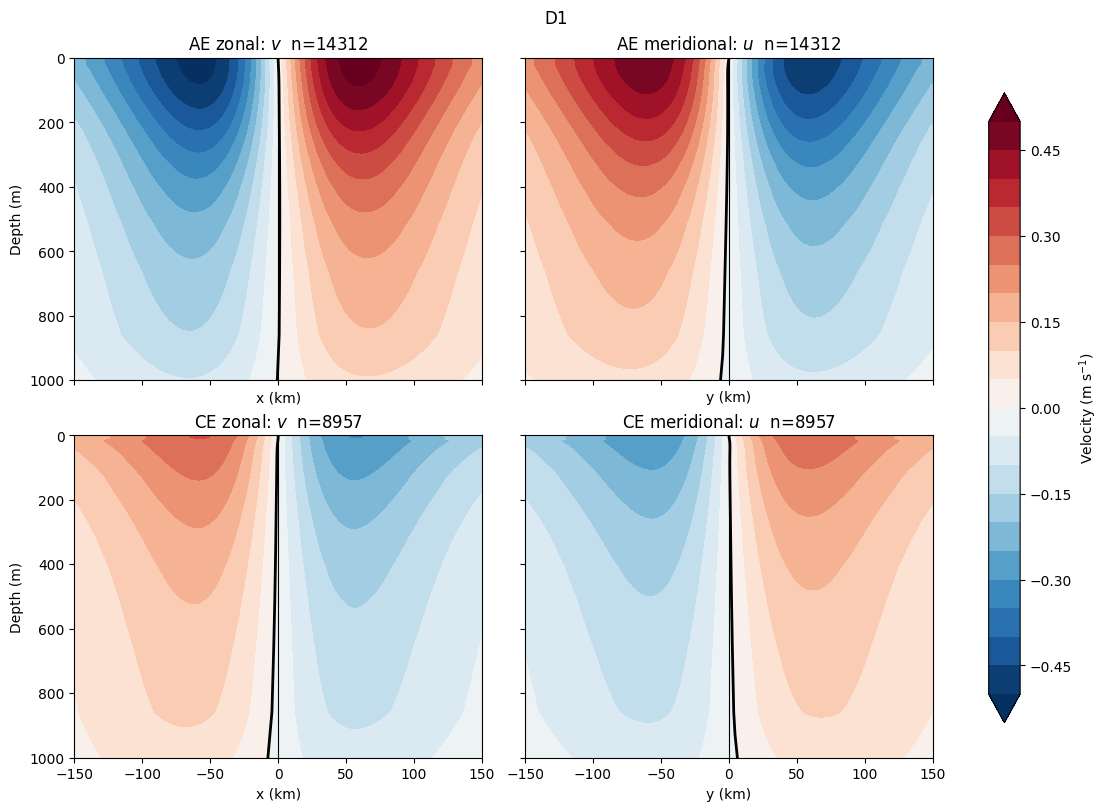

In [16]:
region = 'D1'
X, Y, z_grid, U_AE, V_AE, U_CE, V_CE, fig, axs = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


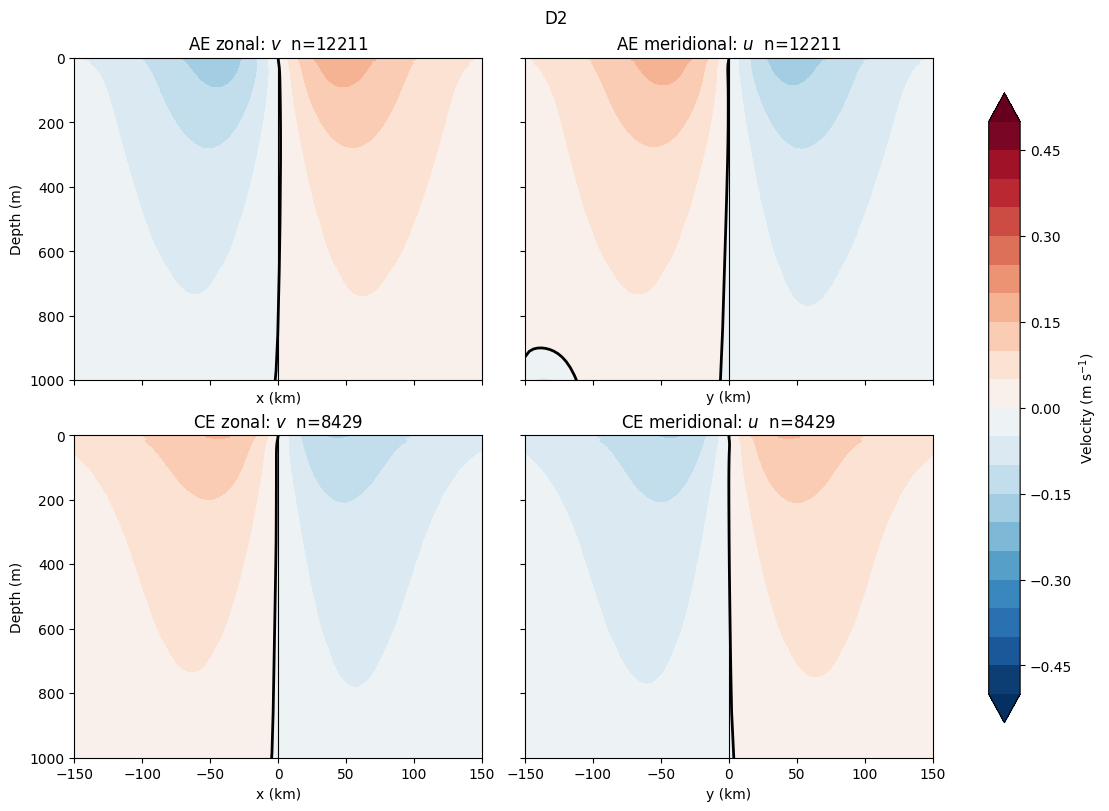

In [17]:
region = 'D2'
X, Y, z_grid, U_AE, V_AE, U_CE, V_CE, fig, axs = regional_composite_eddy_velocity(
    dic_regions[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)


#### Big tilt

In [18]:
dic_regions_big_tilt = {}
df_eddies_big_tilt = df_eddies[
    df_eddies.Eddy.isin(
        df_eddies.groupby('Eddy')['TiltDis'].mean().gt(40).loc[lambda x: x].index
    )
].copy()
for region, allowed_regions in region_groups.items():

    eddies = (
        df_eddies_big_tilt
        .groupby('Eddy')['Region']
        .filter(lambda x: x.isin(allowed_regions).all())
        .index
    )

    dic_regions_big_tilt[region] = df_eddies_big_tilt.loc[eddies].copy()
    

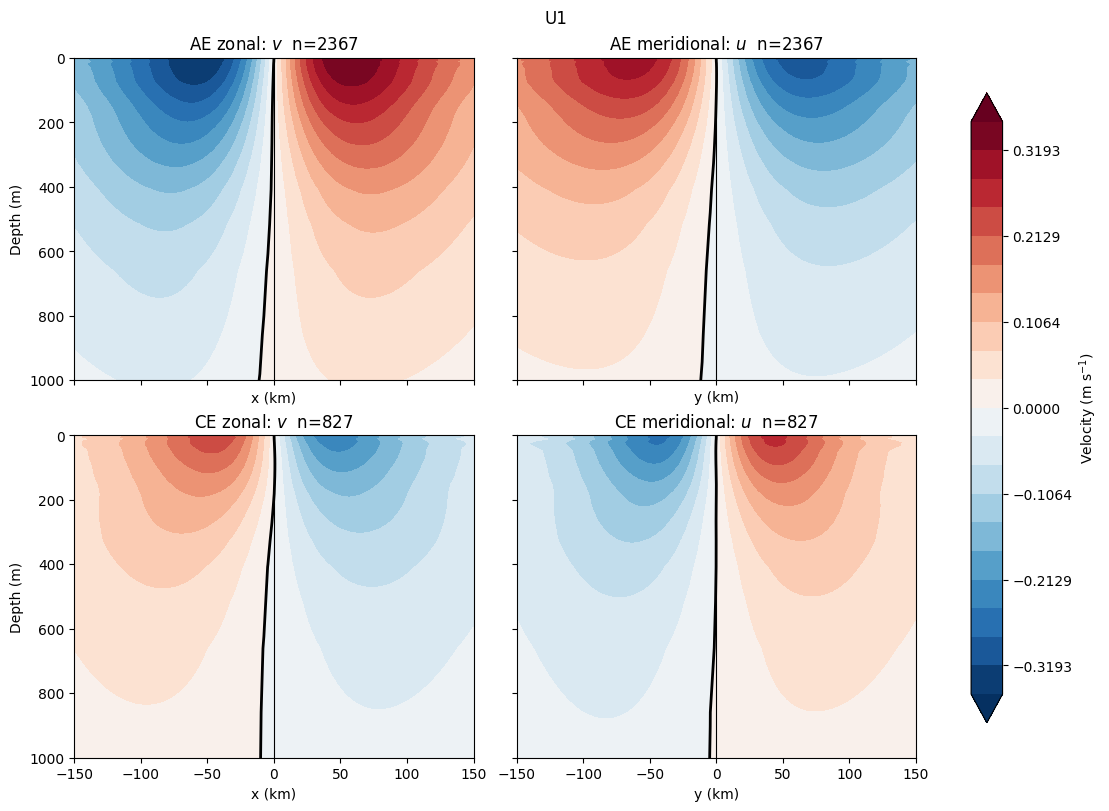

In [19]:
region = 'U1'
X, Y, z_grid, U_AE, V_AE, U_CE, V_CE, fig, axs = regional_composite_eddy_velocity(
    dic_regions_big_tilt[region],
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    title=region
)
